In [111]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

# CIRCUMFERENCE

## Load coordinates

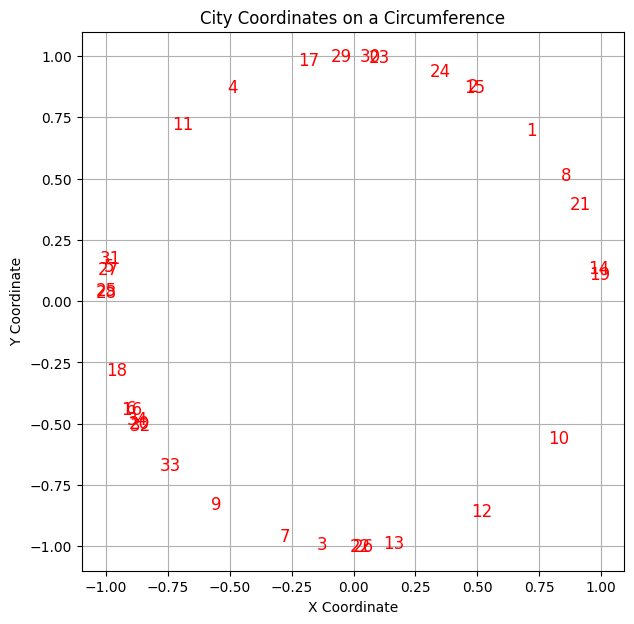

In [112]:
city_index, x_coord, y_coord = np.loadtxt("input/Coords_circumference.dat", unpack=True)
plt.figure(figsize=(7, 7))
plt.scatter(x_coord, y_coord, color='blue', s=0)
# Instead of using points to represent cities put the city index in place of the marker
for i in range(len(city_index)):
    plt.text(x_coord[i], y_coord[i], str(int(city_index[i])), fontsize=12, ha='center', va='center', c="r")
plt.title('City Coordinates on a Circumference')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid()
plt.show()

## Load simulation data

In [113]:
df = pd.read_csv("outputs/poplog_N34_Pop700_Gen700_Circ.dat", sep=r'\s+', comment='#')
df

,Generation,Rank,Fitness,City_1,City_2,City_3,City_4,City_5,City_6,City_7,...,City_26,City_27,City_28,City_29,City_30,City_31,City_32,City_33,City_34,City_35
0,0,0,33.1497,1,10,7,27,6,18,4,...,30,32,16,11,29,15,33,25,24,1
1,0,1,33.6603,1,33,34,20,10,12,29,...,27,6,28,3,16,13,25,24,21,1
2,0,2,33.9584,1,2,8,21,11,30,5,...,22,12,4,9,13,3,18,28,27,1
3,0,3,33.9702,1,23,17,12,10,25,14,...,5,22,7,29,2,4,13,11,31,1
4,0,4,34.2458,1,10,4,17,23,28,29,...,8,12,19,5,27,15,24,2,32,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490695,700,695,23.3599,1,15,2,10,23,32,19,...,11,31,5,27,25,28,18,24,6,1
490696,700,696,23.9735,1,5,9,6,18,28,25,...,2,24,23,20,34,16,14,21,8,1
490697,700,697,23.9735,1,5,9,6,18,28,25,...,2,24,23,20,34,16,14,21,8,1
490698,700,698,24.7957,1,9,2,13,26,22,24,...,32,20,8,34,16,6,18,14,21,1


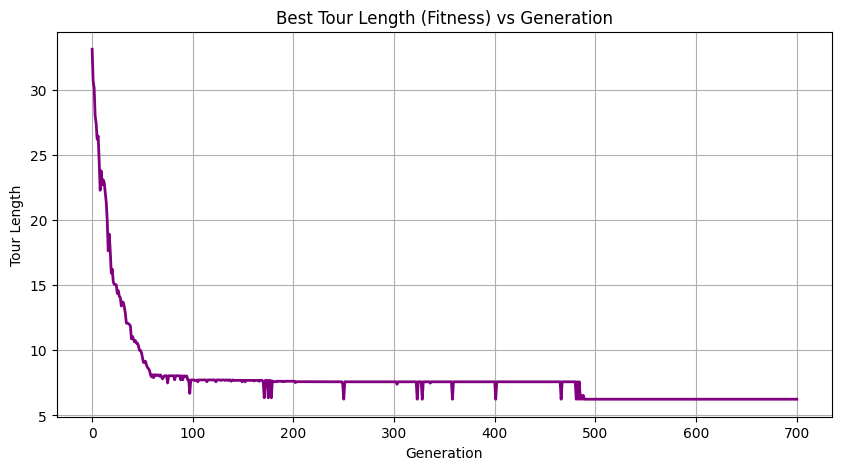

In [114]:
# ==========================================
# PLOT 1: FITNESS VS GENERATION
# ==========================================

# Since Rank 0 is always the best individual of the generation, we just filter for Rank == 0
best_fitness_df = df[df['Rank'] == 0]

plt.figure(figsize=(10, 5))
plt.plot(best_fitness_df['Generation'], best_fitness_df['Fitness'], color='purple', linewidth=2)
plt.title('Best Tour Length (Fitness) vs Generation')
plt.xlabel('Generation')
plt.ylabel('Tour Length')
plt.grid(True)
plt.show()

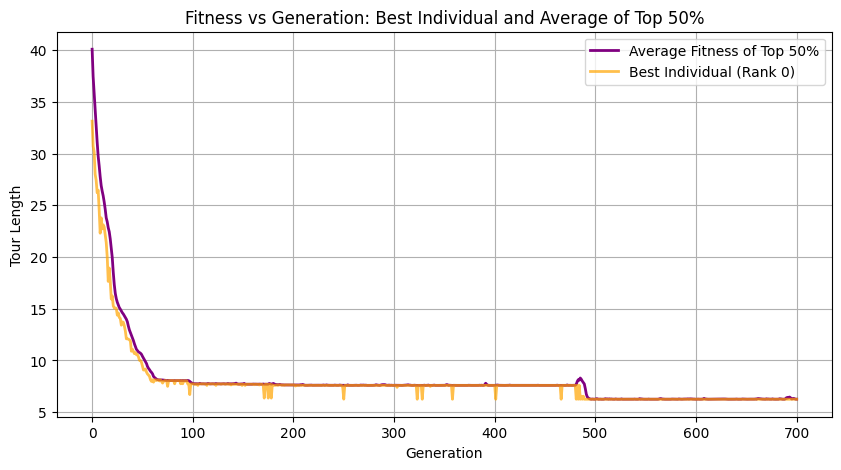

In [115]:
half_population = max(df['Rank'])/2.0
ave_fitness_best_half = df[df['Rank'] < half_population].groupby('Generation')['Fitness'].mean()

plt.figure(figsize=(10, 5))
plt.plot(ave_fitness_best_half.index, ave_fitness_best_half.values, color='purple', linewidth=2, label='Average Fitness of Top 50%')
plt.plot(best_fitness_df['Generation'], best_fitness_df['Fitness'], color='orange', linewidth=2, label='Best Individual (Rank 0)', alpha=0.7)
plt.title('Fitness vs Generation: Best Individual and Average of Top 50%')
plt.xlabel('Generation')
plt.ylabel('Tour Length')
plt.legend()
plt.grid(True)
plt.show()

In [116]:
# ==========================================
# PLOT 2: TOUR VISUALIZATIONS
# ==========================================

# A clean helper function so we don't copy-paste plotting code 3 times!
def plot_tour(generation_num, df, x_coord, y_coord):
    # Extract the row for the best individual of the requested generation
    # .iloc[0] safely grabs the first matching row as a Series
    best_row = df[(df['Generation'] == generation_num) & (df['Rank'] == 0)].iloc[0]
    
    # Extract just the city indices (skipping the first 3 columns: Gen, Rank, Fitness)
    tour = best_row[3:].values.astype(int)
    fitness = best_row['Fitness']
    
    plt.figure(figsize=(7, 7))
    plt.scatter(x_coord, y_coord, color='blue', s=0)
    
    # Plot the city numbers
    for i in range(len(x_coord)):
        plt.text(x_coord[i], y_coord[i], str(i + 1), fontsize=12, ha='center', va='center', c="r")

    # Connect the cities with smaller, cleaner arrows
    for i in range(len(tour) - 1):
        city_a = tour[i] - 1      # -1 to convert 1-based city name to 0-based index
        city_b = tour[i + 1] - 1  
        
        # Calculate the vector differences
        dx = x_coord[city_b] - x_coord[city_a]
        dy = y_coord[city_b] - y_coord[city_a]
        
        plt.arrow(x_coord[city_a], y_coord[city_a], dx, dy,
                  head_width=0.03,        # Much smaller arrowhead width
                  head_length=0.05,       # Much shorter arrowhead length
                  fc='green', ec='green',
                  length_includes_head=True, # Prevents arrow from overshooting the number
                  alpha=0.7)                 # Slight transparency looks nicer
                  
    # Notice we REMOVED the redundant closure loop here!
    
    plt.title(f'Best Tour Visualization: Generation {generation_num}\nFitness: {fitness:.4f}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid()
    plt.show()

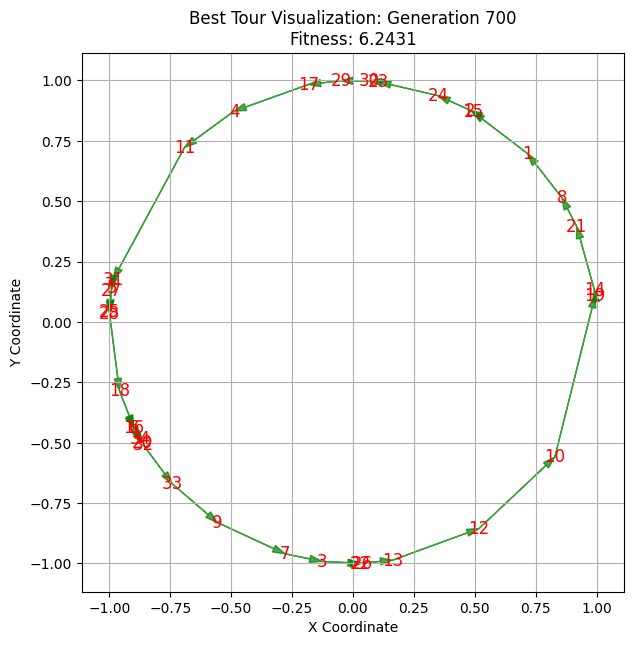

In [117]:
# Generate the 3 plots you requested
#plot_tour(0, df, x_coord, y_coord)     # The initial random mess
#plot_tour(100, df, x_coord, y_coord)   # Mid-way progress
#plot_tour(200, df, x_coord, y_coord)   # The (hopefully!) perfect circle
#plot_tour(500, df, x_coord, y_coord)   # Final result after all generations
plot_tour(700, df, x_coord, y_coord)   # Final result after all generations (last generation)

# Square

## Load coordinates

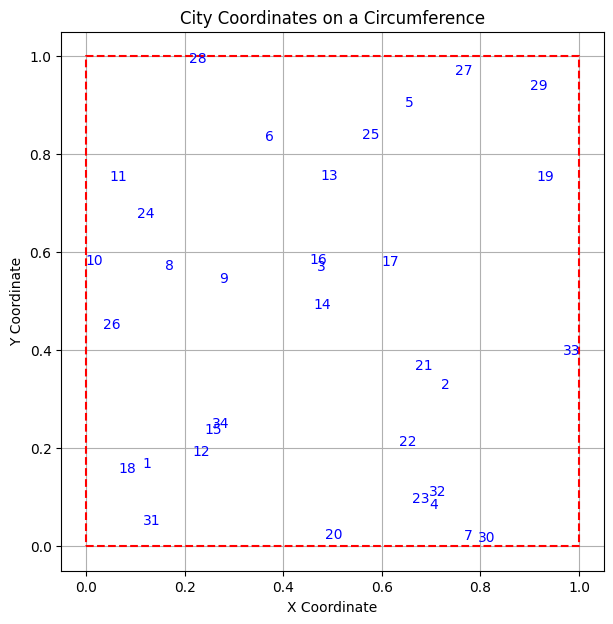

In [118]:
city_index, x_coord, y_coord = np.loadtxt("input/Coords_square.dat", unpack=True)
plt.figure(figsize=(7, 7))
plt.scatter(x_coord, y_coord, color='blue', s=0)
# Instead of using points to represent cities put the city index in place of the marker
for i in range(len(city_index)):
    plt.text(x_coord[i], y_coord[i], str(int(city_index[i])), fontsize=10, ha='center', va='center', c="b")
# Draw the square boundary
plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color='red', linestyle='--')
plt.title('City Coordinates on a Circumference')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid()
plt.show()

## Load data

In [120]:
df = pd.read_csv("outputs/poplog_N34_Pop700_Gen700_Square.dat", sep=r'\s+', comment='#')
df

,Generation,Rank,Fitness,City_1,City_2,City_3,City_4,City_5,City_6,City_7,...,City_26,City_27,City_28,City_29,City_30,City_31,City_32,City_33,City_34,City_35
0,0,0,14.0915,1,7,30,32,15,6,10,...,18,33,23,26,2,21,12,3,11,1
1,0,1,14.9539,1,28,8,3,27,25,14,...,34,19,13,5,6,2,26,22,10,1
2,0,2,15.1274,1,13,30,23,10,11,24,...,31,32,3,14,22,34,26,2,25,1
3,0,3,15.3489,1,30,4,7,22,21,34,...,25,32,13,8,9,20,3,31,18,1
4,0,4,15.4097,1,4,30,9,21,5,10,...,32,24,11,14,8,29,17,2,20,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490695,700,695,10.9358,1,12,15,34,14,17,3,...,10,24,20,28,6,13,25,23,31,1
490696,700,696,10.9655,1,12,15,34,5,4,17,...,24,11,28,6,13,25,27,7,31,1
490697,700,697,11.9912,1,12,15,28,32,30,7,...,9,8,26,10,20,11,19,31,18,1
490698,700,698,11.9912,1,12,15,28,32,30,7,...,9,8,26,10,20,11,19,31,18,1


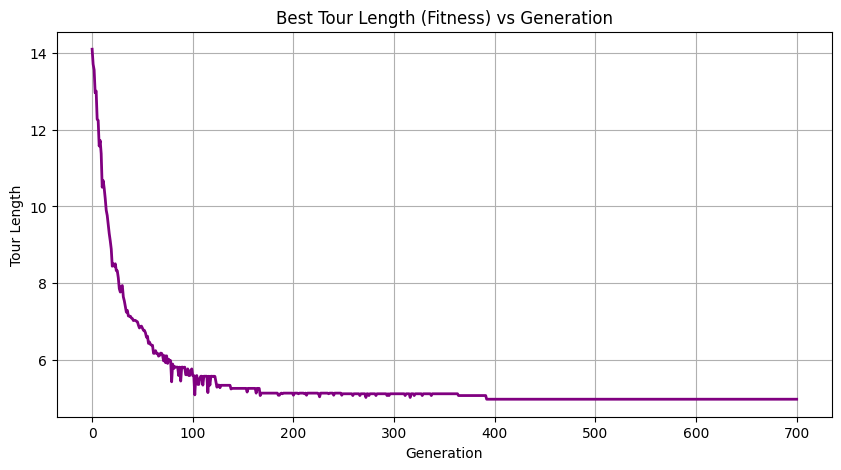

In [121]:
# ==========================================
# PLOT 1: FITNESS VS GENERATION
# ==========================================

# Since Rank 0 is always the best individual of the generation, we just filter for Rank == 0
best_fitness_df = df[df['Rank'] == 0]

plt.figure(figsize=(10, 5))
plt.plot(best_fitness_df['Generation'], best_fitness_df['Fitness'], color='purple', linewidth=2)
plt.title('Best Tour Length (Fitness) vs Generation')
plt.xlabel('Generation')
plt.ylabel('Tour Length')
plt.grid(True)
plt.show()

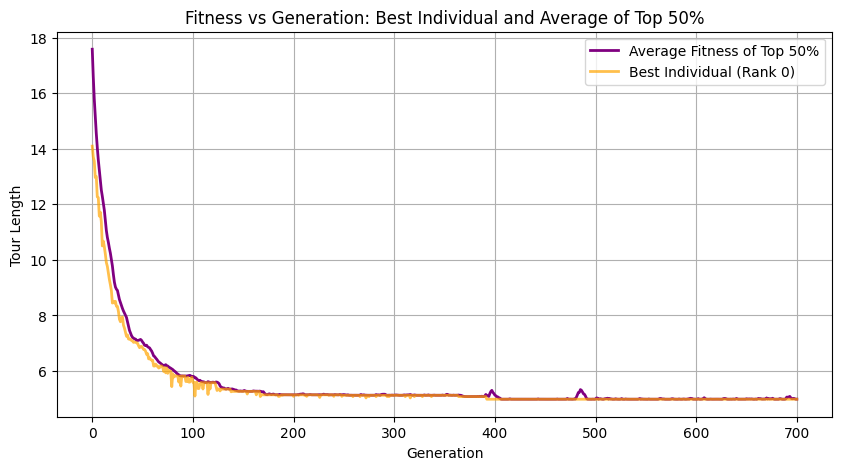

In [122]:
half_population = max(df['Rank'])/2.0
ave_fitness_best_half = df[df['Rank'] < half_population].groupby('Generation')['Fitness'].mean()

plt.figure(figsize=(10, 5))
plt.plot(ave_fitness_best_half.index, ave_fitness_best_half.values, color='purple', linewidth=2, label='Average Fitness of Top 50%')
plt.plot(best_fitness_df['Generation'], best_fitness_df['Fitness'], color='orange', linewidth=2, label='Best Individual (Rank 0)', alpha=0.7)
plt.title('Fitness vs Generation: Best Individual and Average of Top 50%')
plt.xlabel('Generation')
plt.ylabel('Tour Length')
plt.legend()
plt.grid(True)
plt.show()

In [123]:
# ==========================================
# PLOT 2: TOUR VISUALIZATIONS
# ==========================================

# A clean helper function so we don't copy-paste plotting code 3 times!
def plot_tour(generation_num, df, x_coord, y_coord):
    # Extract the row for the best individual of the requested generation
    # .iloc[0] safely grabs the first matching row as a Series
    best_row = df[(df['Generation'] == generation_num) & (df['Rank'] == 0)].iloc[0]
    
    # Extract just the city indices (skipping the first 3 columns: Gen, Rank, Fitness)
    tour = best_row[3:].values.astype(int)
    fitness = best_row['Fitness']
    
    plt.figure(figsize=(7, 7))
    plt.scatter(x_coord, y_coord, color='blue', s=0)
    
    # Plot the city numbers
    for i in range(len(x_coord)):
        plt.text(x_coord[i], y_coord[i], str(i + 1), fontsize=12, ha='center', va='center', c="b")

    # Connect the cities with smaller, cleaner arrows
    for i in range(len(tour) - 1):
        city_a = tour[i] - 1      # -1 to convert 1-based city name to 0-based index
        city_b = tour[i + 1] - 1  
        
        # Calculate the vector differences
        dx = x_coord[city_b] - x_coord[city_a]
        dy = y_coord[city_b] - y_coord[city_a]
        
        plt.arrow(x_coord[city_a], y_coord[city_a], dx, dy,
                  head_width=0.01,        # Much smaller arrowhead width
                  head_length=0.03,       # Much shorter arrowhead length
                  fc='green', ec='green',
                  length_includes_head=True, # Prevents arrow from overshooting the number
                  alpha=0.7)                 # Slight transparency looks nicer
        
    plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color='red', linestyle='--')
                  
    # Notice we REMOVED the redundant closure loop here!
    
    plt.title(f'Best Tour Visualization: Generation {generation_num}\nFitness: {fitness:.4f}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid()
    plt.show()

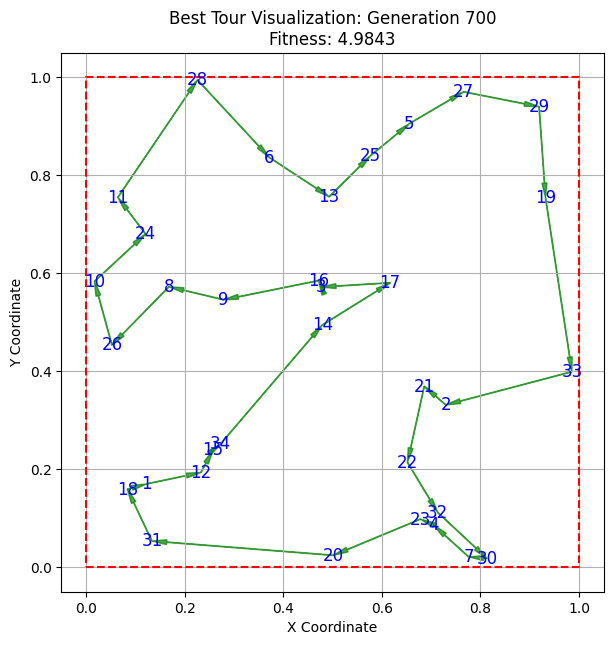

In [124]:
# Generate the 3 plots you requested
# plot_tour(0, df, x_coord, y_coord)     # The initial random mess
# plot_tour(100, df, x_coord, y_coord)   # Mid-way progress
# plot_tour(200, df, x_coord, y_coord)   # The (hopefully!) perfect circle
# plot_tour(500, df, x_coord, y_coord)   # Final result after all generations
plot_tour(700, df, x_coord, y_coord)   # Final result after all generations (last generation)